Derived pure dephasing time Tphi = 133.33 us

Final density matrix (should be ~ground state |0><0| at T=0):
[[0.9932+0.j 0.    +0.j]
 [0.    +0.j 0.0068-0.j]]
Final <Z> = 0.98647  (expected: +1.0, i.e. ground state)
Final populations: P(0) = 0.99323, P(1) = 0.00677

Saved plot to step2_lindblad_steady_state.png
Max deviation from analytical T1 curve: 3.25e-04


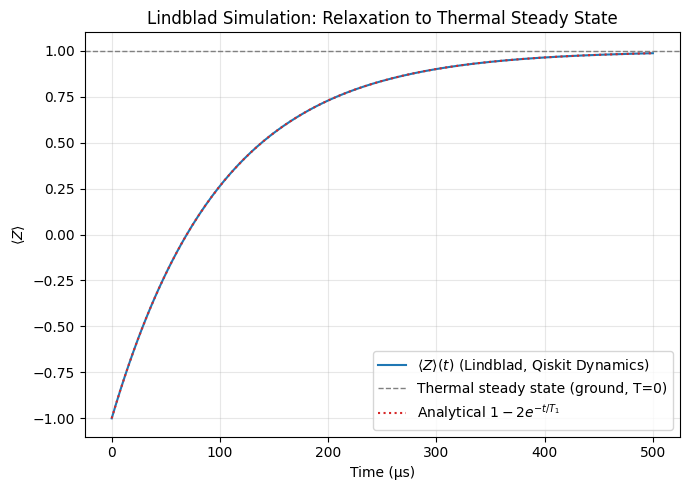

In [6]:


import numpy as np
import matplotlib.pyplot as plt
from qiskit_dynamics import Solver


# 1. Pauli operators

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
sigma_minus = np.array([[0, 1], [0, 0]], dtype=complex)  # maps |1> -> |0>


def bloch_vector(rho):
    return (np.real(np.trace(rho @ sx)),
            np.real(np.trace(rho @ sy)),
            np.real(np.trace(rho @ sz)))



# Physical parameters
wq = 2 * np.pi * 5e9      # qubit angular frequency, omega_q/2pi = 5 GHz
T1 = 100e-6               # energy relaxation time
T2 = 80e-6                # (Hahn-echo-like) dephasing time target

# From 1/T2 = 1/(2T1) + 1/Tphi solve for the dephasing time Tphi
Tphi = 1 / (1 / T2 - 1 / (2 * T1))
print(f"Derived pure dephasing time Tphi = {Tphi*1e6:.2f} us")


# 3. Lindblad jump operators
L1 = np.sqrt(1 / T1) * sigma_minus   # energy relaxation
L2 = np.sqrt(1 / (2*Tphi)) * sz          # pure dephasing


# 4. Build the Solver

# Static qubit Hamiltonian in the lab frame: H0 = (wq/2) * sz
static_hamiltonian = 0.5 * wq * sz

solver = Solver(
    static_hamiltonian=static_hamiltonian,
    static_dissipators=[L1, L2],
    rotating_frame=static_hamiltonian,   # move into the qubit's own rotating frame

)


#Simulate free decay from the excited state

rho0 = np.array([[0, 0], [0, 1]], dtype=complex)  #  |1><1|

t_final = 5 * T1
n_points = 250
t_eval = np.linspace(0, t_final, n_points)

result = solver.solve(
    t_span=[0, t_final],
    y0=rho0,
    t_eval=t_eval,
    method="RK45",
)

rx_t, ry_t, rz_t = [], [], []
for rho_t in result.y:
    rx, ry, rz = bloch_vector(rho_t)
    rx_t.append(rx); ry_t.append(ry); rz_t.append(rz)

rx_t, ry_t, rz_t = map(np.array, (rx_t, ry_t, rz_t))


# 6. Check thermal steady state

rho_final = result.y[-1]
print("\nFinal density matrix (should be ~ground state |0><0| at T=0):")
print(np.round(rho_final, 4))
print(f"Final <Z> = {rz_t[-1]:.5f}  (expected: +1.0, i.e. ground state)")
print(f"Final populations: P(0) = {np.real(rho_final[0,0]):.5f}, "
      f"P(1) = {np.real(rho_final[1,1]):.5f}")

# 7. Plot

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t_eval * 1e6, rz_t, label=r"$\langle Z \rangle(t)$ (Lindblad, Qiskit Dynamics)")
ax.axhline(1.0, color="gray", ls="--", lw=1, label="Thermal steady state (ground, T=0)")
ax.plot(t_eval * 1e6, 1 - 2 * np.exp(-t_eval / T1), ":", color="tab:red",
         label=r"Analytical $1-2e^{-t/T_1}$")
ax.set_xlabel("Time (µs)")
ax.set_ylabel(r"$\langle Z \rangle$")
ax.set_title("Lindblad Simulation: Relaxation to Thermal Steady State")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("step2_lindblad_steady_state.png", dpi=150)
print("\nSaved plot to step2_lindblad_steady_state.png")

max_dev = np.max(np.abs(rz_t - (1 - 2 * np.exp(-t_eval / T1))))
print(f"Max deviation from analytical T1 curve: {max_dev:.2e}")


In [4]:
!pip install qiskit_dynamics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.9 MB/s eta 0:00:00
